# 6_Select_color_and_zoom

Autor: Jorge García Cevallos

En este notebook, aplicaremos los conceptos desarrollados en los capítulos 4 y 5, combinando la detección de color con transformaciones geométricas como el zoom y el desplazamiento. Esta integración permite no solo identificar colores específicos dentro de una imagen, sino también manipular la visualización para enfocar y analizar con mayor precisión las áreas de interés.

### Librerias

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math

### Función que muestra los detalles de la imagen. 

In [2]:
# Función para mostrar información básica sobre una imagen, incluyendo su tamaño, valor máximo y valor mínimo de píxeles.
# (Antigua función)
def howis(img):
  print('size = ',img.shape)
  print('max  = ',np.max(img))
  print('min  = ',np.min(img))

In [3]:
# Función para mostrar una imagen utilizando la biblioteca matplotlib.
def plot_show_image(imagen):
    imageRGB = imagen[:,:,[2,1,0]] 
    plt.imshow(imageRGB)
    plt.show()

In [8]:
# Interpolation using nearest integer towards zero
def geo_transformation(X,A,Yshape=None):

  if Yshape is None:
    (N,M) = X.shape
  else:
    (N,M) = Yshape

  Y = np.zeros((N,M),np.uint8) # Create an N x M matrix filled with zeros, with each element represented as an unsigned 8-bit integer. 

  m = np.ones((N*M,3)) # Create a matrix with dimensions N*M x 3 filled with ones
  t = 0

  for i in range(N):
    for j in range(M):
      m[t,0:3] = [i,j,1]
      t = t+1

  m0  = np.dot(A,m.T)          # (i,j) -> (i0,j0) using equation explained above
  mpf = np.fix(m0).astype(int) # nearest integer towards zero
  
  # verification: does the pixel (i0,j0) belong to the image?
  i0 = mpf[0,:]
  j0 = mpf[1,:]
  kti = np.logical_and(i0>=0,i0<N)
  ktj = np.logical_and(j0>=0,j0<M)
  kt  = np.logical_and(kti,ktj)
  
  # output image
  t = 0
  for i in range(N):
    for j in range(M):
      if kt[t]:
        Y[i,j] = X[i0[t],j0[t]]
      t = t+1
  return Y

## Leer Imagen a color

In [9]:
Icv = cv.imread("icosDriverMotor.jpeg")
howis(Icv)

size =  (1600, 738, 3)
max  =  255
min  =  0


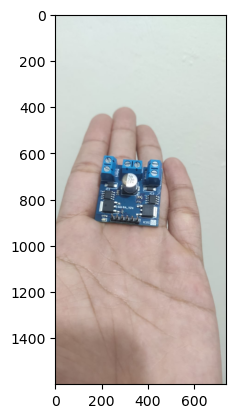

In [10]:
# Convertimos la imagen de BGR a RGB reordenando los canales.
plot_show_image(Icv)

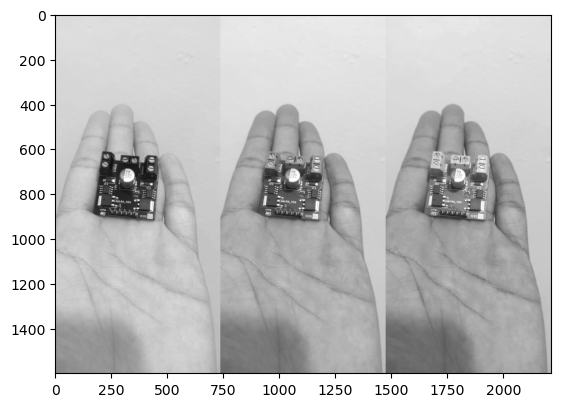

In [11]:
# Convierte una imagen de formato BGR a RGB, extrae los canales de color R, G y B, 
# y luego concatena los canales para formar una imagen RGB. Finalmente, muestra la imagen.
I = Icv[:,:,[2,1,0]]
R = I[:,:,0]
G = I[:,:,1]
B = I[:,:,2]
RGB = np.concatenate((R,G,B),axis=1)
plt.imshow(RGB,cmap='gray')
plt.show()

### Convertimos a blanco y negro

size =  (1600, 738)
max  =  255
min  =  23


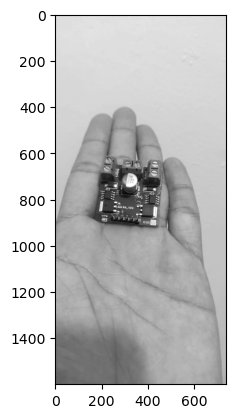

In [12]:
Rd = R.astype(float)
Gd = G.astype(float)
Bd = B.astype(float)
# weighted average
k  = (1/3,1/3,1/3)
Zd = k[0]*Rd+k[1]*Gd+k[2]*Bd
Z  = Zd.astype(int)
howis(Z)
plt.imshow(Z,cmap='gray')
plt.show()

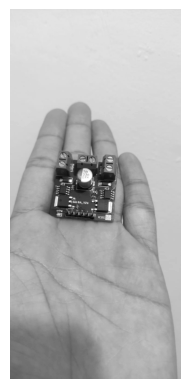

In [13]:
imagen_gris = cv.cvtColor(Icv, cv.COLOR_BGR2GRAY)
plt.imshow(imagen_gris, cmap='gray')
plt.axis('off')
plt.show()

### Segmentación de una nueva imagen utilizando la fórmula antigua.

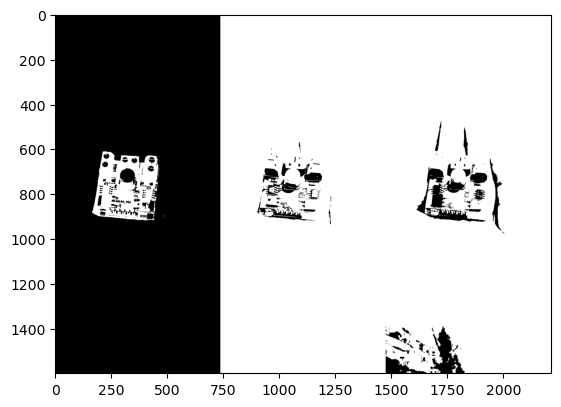

In [17]:
# Creación de máscaras individuales para los canales de color R, G y B, basadas en umbrales específicos,
# y luego se concatenan horizontalmente para formar una imagen binaria compuesta. Finalmente, se muestra la imagen binaria.
Sr = R<90
Sg = G>75
Sb = B>105
Srgb = np.concatenate((Sr,Sg,Sb),axis=1)
plt.imshow(Srgb,cmap='gray')
plt.show()

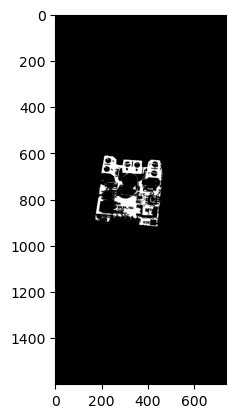

In [18]:
# Se realiza una operación de 'AND' lógico entre las máscaras individuales para los canales de color R, G y B,
# y luego se aplica nuevamente una operación 'AND' lógico entre los resultados de las combinaciones anteriores.
# Finalmente, se muestra la imagen binaria resultante, escalada para valores de 0 a 255.
Srg = np.logical_and(Sr,Sg)
S   = np.logical_and(Srg,Sb)
plt.imshow(S*255,cmap='gray')
plt.show()

### Segmentación utilizando la nueva fórmula utilizando OpenCV.

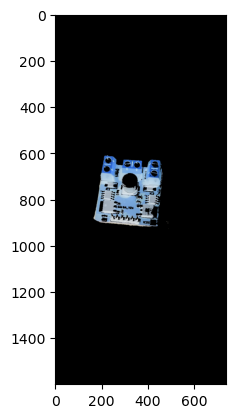

In [19]:
# Definir el rango de azul en BGR
rango_bajo_azul = np.array([0, 0,0])  # Valor mínimo de B,G,R para el azul
rango_alto_azul = np.array([255, 170, 88])  # Valor máximo de B,G,R para el azul

# Crear una máscara de los píxeles que están en el rango de azul
mascara_azul = cv.inRange(Icv, rango_bajo_azul, rango_alto_azul)

# Aplicar la máscara a la imagen original
objeto_azul = cv.bitwise_and(Icv, Icv, mask=mascara_azul)

plt.imshow(objeto_azul*255,cmap='gray')
plt.show()

### Searching (imin,jmin) and (imax,jmax) in the segmented region

In [20]:
(N,M) = S.shape
imin = 1000
imax = 0
jmin = 1000
jmax = 0
for i in range(N):
  for j in range(M):
    if S[i,j]>0:
      if i<imin:
        imin = i
      if i>imax:
        imax = i
      if j<jmin:
        jmin = j
      if j>jmax:
        jmax = j

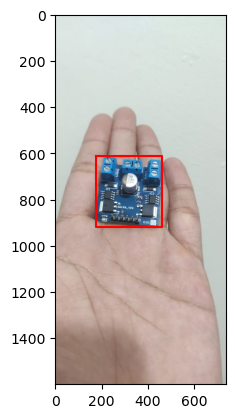

In [21]:
y = [imin,imin,imax,imax,imin]
x = [jmin,jmax,jmax,jmin,jmin]
plt.imshow(I)
plt.plot(x,y,color = 'red')
plt.show()


## Procedememos a usar sus variables para hacer zoom y centrarlo

In [50]:
# Calcula el tamaño de la imagen y la escala de zoom en función del ancho de la región de interés
image_height,image_width = R.shape
horizontal_span = jmax - jmin
zoom_scale = horizontal_span/image_width

# Calcula el número de veces que la región cabe en el ancho de la imagen y ajusta el alto en consecuencia
tiles_in_width = math.floor(image_width/horizontal_span)
new_height= (imax-imin)*tiles_in_width

# Calcula el espacio restante en altura y el desplazamiento vertical para centrar la imagen
remaining_height = image_height-new_height
vertical_offset = math.floor(remaining_height/2)


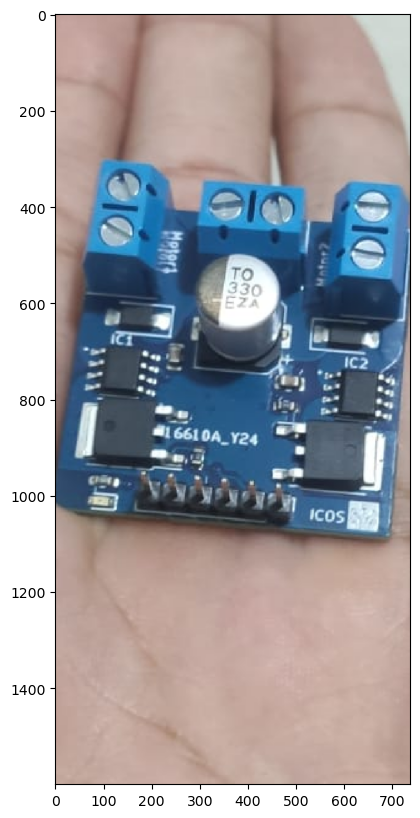

In [25]:
s = zoom_scale # Factor de zoom

tx = jmin  # Traslación en X
ty = vertical_offset  # Traslación en Y
a11 = s
a12 = 0
a13 = ty

a21 = 0
a22 = s
a23 = tx

a1 = np.array([a11,a12,a13])
a2 = np.array([a21,a22,a23])

A  = np.vstack([a1,a2])

Yr = geo_transformation(R,A)
Yg = geo_transformation(G,A)
Yb = geo_transformation(B,A)

Y_rgb = np.stack((Yr, Yg, Yb), axis=-1)

# Muestra la imagen resultante
plt.figure(figsize=(10,10))
plt.imshow(Y_rgb)
plt.show()



### Este código detecta contornos grandes en una imagen y dibuja rectángulos alrededor de ellos. (remplazo del anterior)

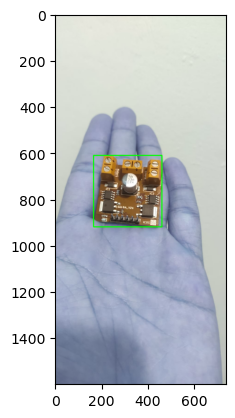

In [26]:
img = Icv.copy()
contornos, _ = cv.findContours(mascara_azul, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Define un umbral de área para lo que consideras "grande"
umbral_area = 150 

# Filtra solo los contornos grandes
contornos_grandes = [contorno for contorno in contornos if cv.contourArea(contorno) > umbral_area]

# Dibuja un rectángulo alrededor de cada contorno grande
for contorno in contornos_grandes:
    x, y, w, h = cv.boundingRect(contorno)
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 4)  

plt.imshow(img, cmap='gray')
plt.show()

## Procedememos a usar sus variables para hacer zoom y centrarlo (Usando lo nuevo)

In [51]:
x = y = w = h = 0
for contorno in contornos_grandes:
    x, y, w, h = cv.boundingRect(contorno)

print(x,y,w,h)


166 611 295 309


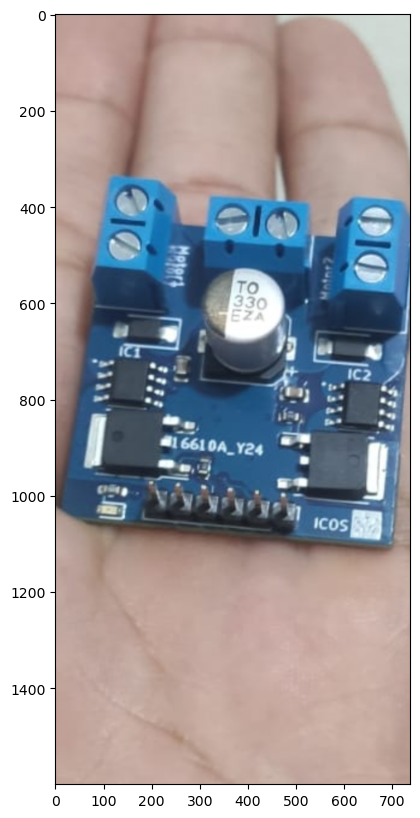

In [53]:
# Calcula el factor de zoom basado en el ancho de la región de interés y redimensiona la imagen en consecuencia
zoom_factor = img.shape[1]/w
new_size = (int(img.shape[1] * zoom_factor), int(img.shape[0] * zoom_factor))
zoomed_img = cv.resize(img, new_size, interpolation=cv.INTER_LINEAR)

# Calcula la posición vertical para centrar la altura de la región en la imagen
image_height = img.shape[0]
vertical_position = (image_height - h) / 2
vertical_position = math.floor(vertical_position + h) / 2

# Define los desplazamientos en X e Y (pueden ser positivos o negativos)
dx = -(zoom_factor*x)  # Desplazamiento en X (positivo hacia la derecha, negativo hacia la izquierda)
vertical_offset = img.shape[1]
dy = -(zoom_factor*vertical_position)  # Desplazamiento en Y (positivo hacia abajo, negativo hacia arriba)

# Obtén las dimensiones de la imagen
rows, cols = zoomed_img.shape[:2]

# Crea la matriz de transformación para el desplazamiento
M = np.float32([[1, 0, dx], [0, 1, dy]])

# Aplica la transformación a la imagen
translated_img = cv.warpAffine(zoomed_img, M, (cols, rows))

final_img = translated_img[0:img.shape[0], 0:img.shape[1]]

# Muestra la imagen con zoom manteniendo el tamaño original
plt.figure(figsize=(10,10))
plt.imshow(cv.cvtColor(final_img, cv.COLOR_BGR2RGB))
plt.show()
